In [30]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

import io 
import PIL 
import json




In [31]:
try:
    df = pd.read_csv('../data/pns2019/pns2019.csv')

    df = df.rename(columns={
            "C008" : 'Idade',
            "Q11009": 'TOC',
            "P00104": 'Peso',
            "P00404": 'Altura',
            "V0001": 'Estado'
        }
    )

    map_estados = {
        '11' :'Rondônia',
        '12' : 'Acre',
        '13' : 'Amazonas',
        '14' : 'Roraima',
        '15' : 'Pará',
        '16' : 'Amapá',
        '17' : 'Tocantins',
        '21' : 'Maranhão',
        '22' : 'Piaui',
        '23': 'Ceará',
        '24':'Rio Grande do Norte',
        '25' :'Paraiba',
        '26' :'Pernambuco',
        '27':'Alagoas',
        '28':'Sergipe',
        '29':'Bahia',
        '31':'Minas Gerais',
        '32':'Espirito Santo',
        '33':'Rio de Janeiro',
        '35':'São Paulo',
        '41':'Paraná',
        '42':'Santa Catarina',
        '43':'Rio Grande do Sul',
        '50':'Mato Grosso do Sul',
        '51':'Mato Grosso',
        '52':'Goiás',
        '53':'Distrito Federal',
    }

    map_regiao = {
        'Rondônia': 'Norte',
        'Acre': 'Norte',
        'Amazonas': 'Norte',
        'Roraima': 'Norte',
        'Pará': 'Norte',
        'Amapá': 'Norte',
        'Tocantins': 'Norte',
        'Maranhão': 'Nordeste',
        'Piaui': 'Nordeste',
        'Ceará': 'Nordeste',
        'Rio Grande do Norte': 'Nordeste',
        'Paraiba': 'Nordeste',
        'Pernambuco': 'Nordeste',
        'Alagoas': 'Nordeste',
        'Sergipe': 'Nordeste',
        'Bahia': 'Nordeste',
        'Minas Gerais': 'Sudeste',
        'Espirito Santo': 'Sudeste',
        'Rio de Janeiro': 'Sudeste',
        'São Paulo': 'Sudeste',
        'Paraná': 'Sul',
        'Santa Catarina': 'Sul',
        'Rio Grande do Sul': 'Sul',
        'Mato Grosso do Sul': 'Centro-Oeste',
        'Mato Grosso': 'Centro-Oeste',
        'Goiás': 'Centro-Oeste',
        'Distrito Federal': 'Centro-Oeste'
    }

    
   
    df["Estado"] = df["Estado"].astype(str).map(map_estados)
    df["Regiao"] = df["Estado"].map(map_regiao)

    df_faixa_etaria =  df[ (df["Idade"] >= 30) & (df["Idade"] < 60) ]
     
except Exception as e:
    print(f'Erro ao abrir csv:  {e}')

In [32]:
# df.shape
# df.info()
# df.describe()

In [33]:
df_toc = df_faixa_etaria[(df_faixa_etaria ["TOC"] == 1) ]



In [34]:

cols = ["Q00201","Q03001","Q060","Q06306","Q068",
        "Q074","Q079","Q088","Q092","Q11006","Q11604","Q120","Q128","Q124","Q084"]

df_bem = df_faixa_etaria[df_faixa_etaria[cols].eq(2).all(axis=1)]

df_bem

,Estado,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA,Regiao
10,Rondônia,1110011,110000016,3,1,2019,8.0,1,1,1.0,...,9.0,4000.0,500.0,3.0,NaN,4.0,NaN,1.0,20210825,Norte
18,Rondônia,1110011,110000016,4,1,2019,1.0,1,1,1.0,...,7.0,324.0,324.0,2.0,NaN,1.0,NaN,NaN,20210825,Norte
22,Rondônia,1110011,110000016,7,1,2019,3.0,1,1,1.0,...,7.0,2998.0,999.0,4.0,NaN,3.0,NaN,NaN,20210825,Norte
26,Rondônia,1110011,110000016,8,1,2019,4.0,1,1,1.0,...,NaN,998.0,250.0,1.0,NaN,NaN,2.0,NaN,20210825,Norte
29,Rondônia,1110011,110000016,9,1,2019,2.0,1,1,1.0,...,2.0,1400.0,700.0,3.0,NaN,1.0,NaN,NaN,20210825,Norte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293654,Distrito Federal,5310220,530041727,4,1,2019,2.0,2,1,1.0,...,1.0,2000.0,1000.0,4.0,NaN,1.0,NaN,NaN,20210825,Centro-Oeste
293656,Distrito Federal,5310220,530041727,5,1,2019,3.0,2,1,1.0,...,1.0,2820.0,940.0,3.0,NaN,1.0,NaN,NaN,20210825,Centro-Oeste
293689,Distrito Federal,5310220,530044434,1,1,2019,2.0,2,1,1.0,...,9.0,5500.0,2750.0,5.0,NaN,3.0,NaN,NaN,20210825,Centro-Oeste
293690,Distrito Federal,5310220,530044434,2,1,2019,1.0,2,1,1.0,...,5.0,7200.0,7200.0,7.0,NaN,3.0,NaN,NaN,20210825,Centro-Oeste


In [35]:
df_juncao = pd.concat([df_toc, df_bem], ignore_index=True)
df_juncao

,Estado,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA,Regiao
0,Rondônia,1110011,110005539,5,1,2019,10.0,1,1,1.0,...,NaN,8994.0,899.0,3.0,NaN,NaN,NaN,NaN,20210825,Norte
1,Rondônia,1110012,110017590,6,1,2019,2.0,1,1,1.0,...,2.0,6100.0,3050.0,6.0,NaN,NaN,NaN,NaN,20210825,Norte
2,Rondônia,1152011,110020167,8,1,2019,1.0,1,4,1.0,...,NaN,998.0,998.0,3.0,NaN,NaN,NaN,NaN,20210825,Norte
3,Rondônia,1152013,110017035,15,1,2019,3.0,1,4,1.0,...,8.0,1300.0,433.0,2.0,NaN,3.0,NaN,4.0,20210825,Norte
4,Acre,1210010,120002727,14,1,2019,5.0,1,1,1.0,...,8.0,6000.0,1500.0,4.0,NaN,2.0,NaN,NaN,20210825,Norte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19868,Distrito Federal,5310220,530041727,4,1,2019,2.0,2,1,1.0,...,1.0,2000.0,1000.0,4.0,NaN,1.0,NaN,NaN,20210825,Centro-Oeste
19869,Distrito Federal,5310220,530041727,5,1,2019,3.0,2,1,1.0,...,1.0,2820.0,940.0,3.0,NaN,1.0,NaN,NaN,20210825,Centro-Oeste
19870,Distrito Federal,5310220,530044434,1,1,2019,2.0,2,1,1.0,...,9.0,5500.0,2750.0,5.0,NaN,3.0,NaN,NaN,20210825,Centro-Oeste
19871,Distrito Federal,5310220,530044434,2,1,2019,1.0,2,1,1.0,...,5.0,7200.0,7200.0,7.0,NaN,3.0,NaN,NaN,20210825,Centro-Oeste


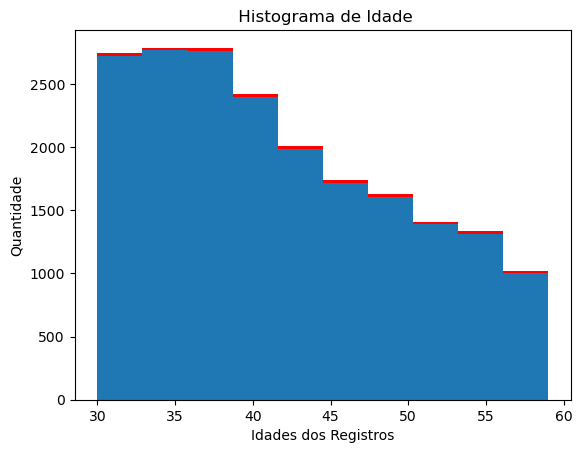

In [36]:
plt.hist(df_juncao['Idade'],color='red')
plt.hist(df_bem['Idade'])
plt.title(' Histograma de Idade')
plt.xlabel('Idades dos Registros')
plt.ylabel('Quantidade')
plt.show()

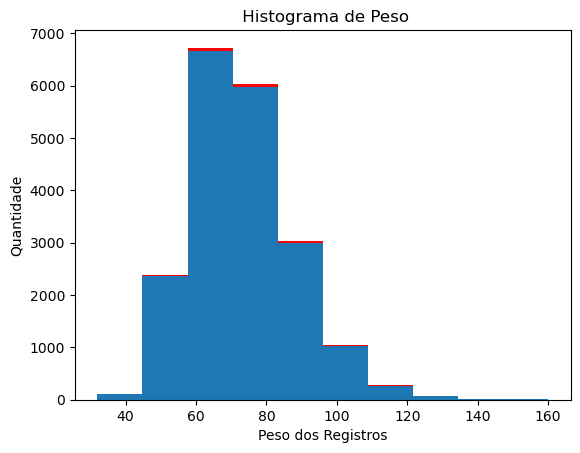

In [37]:
plt.hist(df_juncao['Peso'],color='red')
plt.hist(df_bem['Peso'])
plt.title(' Histograma de Peso')
plt.xlabel('Peso dos Registros')
plt.ylabel('Quantidade')
plt.show()

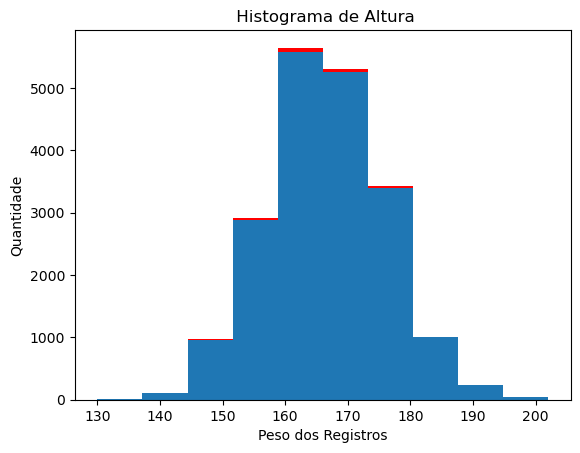

In [38]:
plt.hist(df_juncao['Altura'],color='red')
plt.hist(df_bem['Altura'])
plt.title(' Histograma de Altura')
plt.xlabel('Peso dos Registros')
plt.ylabel('Quantidade')
plt.show()

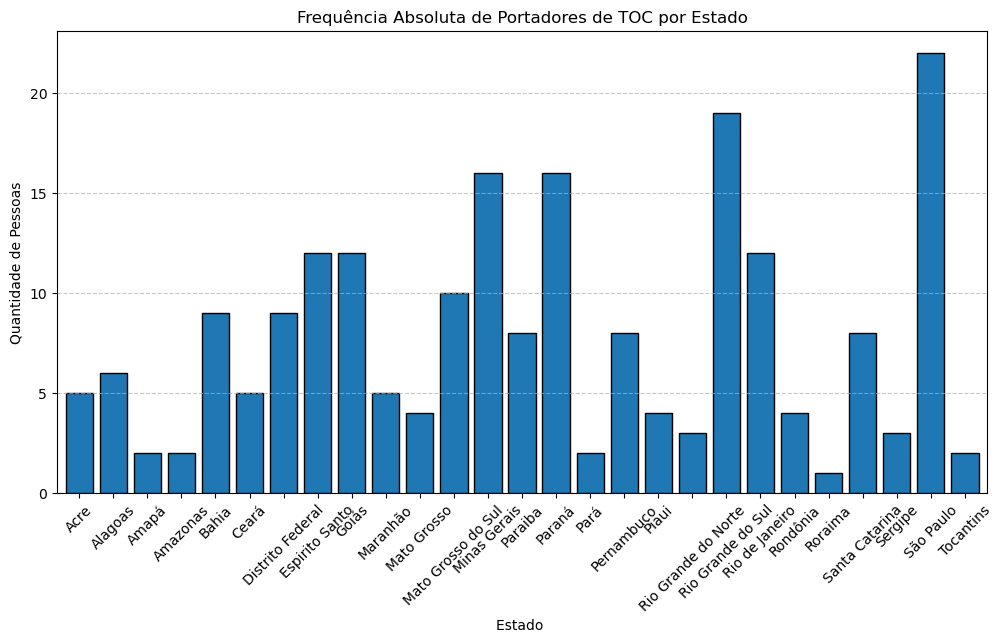

In [39]:
contagem_toc_estado = df_toc['Estado'].value_counts().sort_index()
contagem_toc_estado.plot(kind ='bar', edgecolor='black', figsize=(12, 6), width=0.8)
plt.title('Frequência Absoluta de Portadores de TOC por Estado')
plt.xlabel('Estado ')
plt.ylabel('Quantidade de Pessoas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

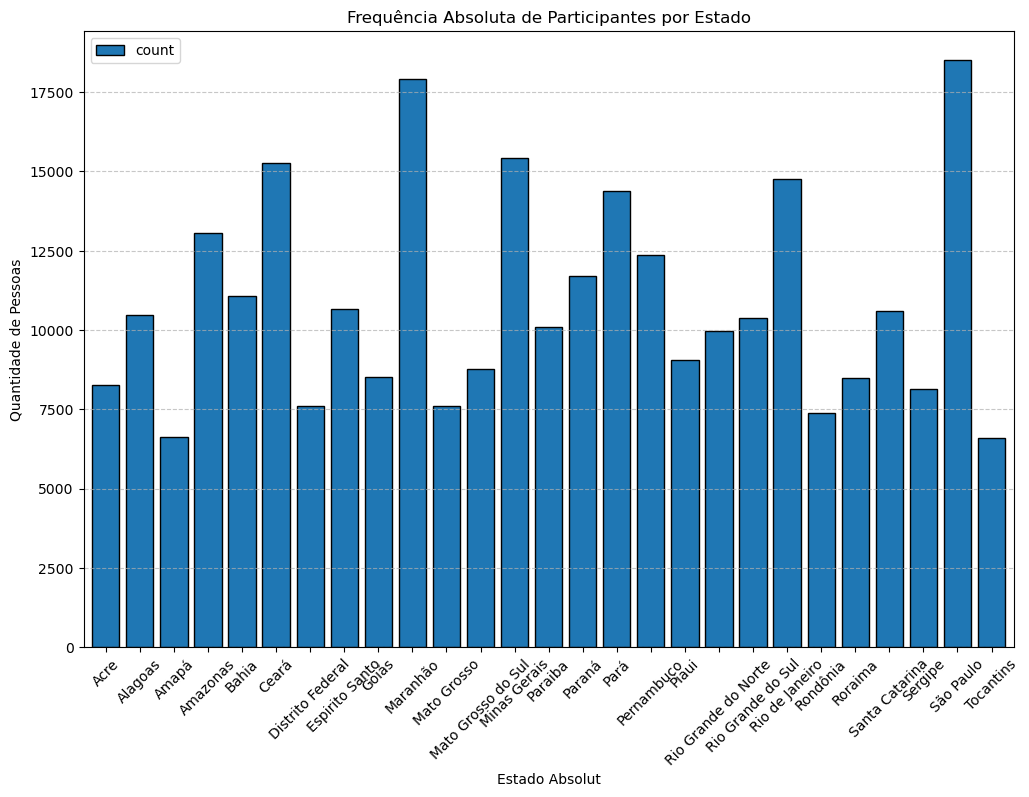

In [40]:
contagem_geral_estado = df['Estado'].value_counts().sort_index()
contagem_geral_estado.plot(kind ='bar', edgecolor='black', figsize=(12, 8), width=0.8,)
plt.title('Frequência Absoluta de Participantes por Estado')
plt.xlabel('Estado Absolut')
plt.ylabel('Quantidade de Pessoas')
plt.legend()
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


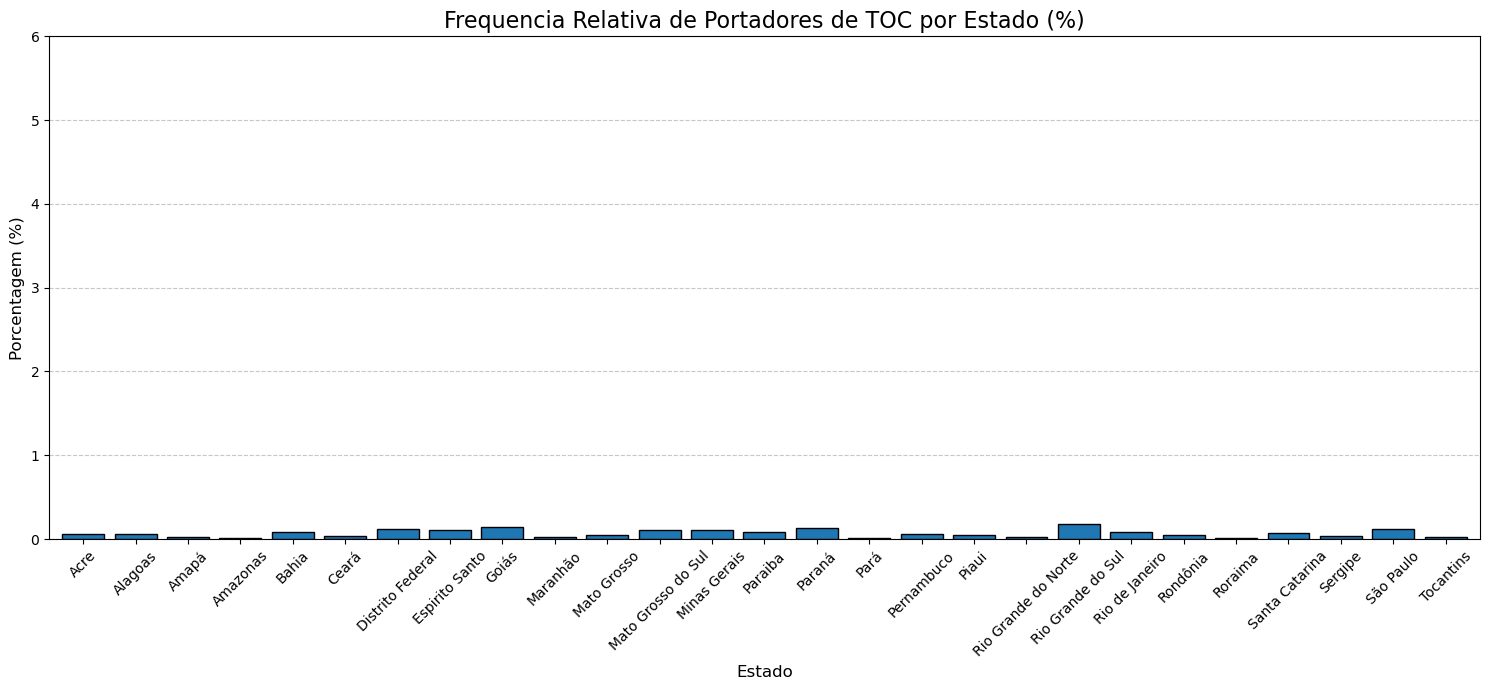

In [41]:
porcentagem_toc_estado = (contagem_toc_estado / contagem_geral_estado) * 100
porcentagem_maior_estado = int(contagem_geral_estado.max() / contagem_geral_estado.sum()* 100)
plt.figure(figsize=(15, 7))
porcentagem_toc_estado.plot(kind='bar', edgecolor='black', width=0.8)
plt.ylim(0,porcentagem_maior_estado)
plt.title('Frequencia Relativa de Portadores de TOC por Estado (%)', fontsize=16)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

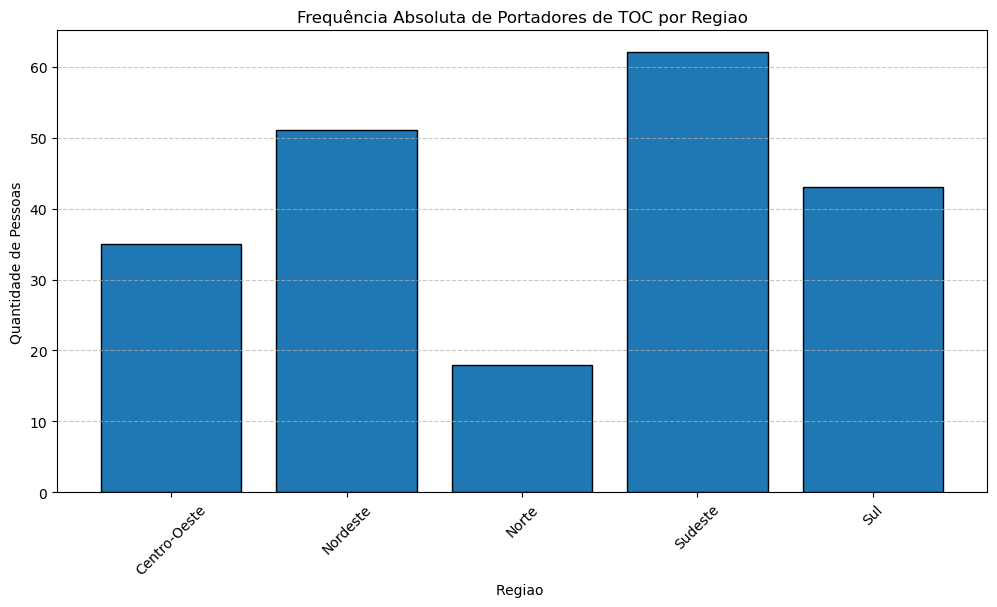

In [48]:
contagem_toc_regiao = df_toc['Regiao'].value_counts().sort_index()
contagem_toc_regiao.plot(kind ='bar', edgecolor='black', figsize=(12, 6), width=0.8)
plt.title('Frequência Absoluta de Portadores de TOC por Regiao')
plt.xlabel('Regiao ')
plt.ylabel('Quantidade de Pessoas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

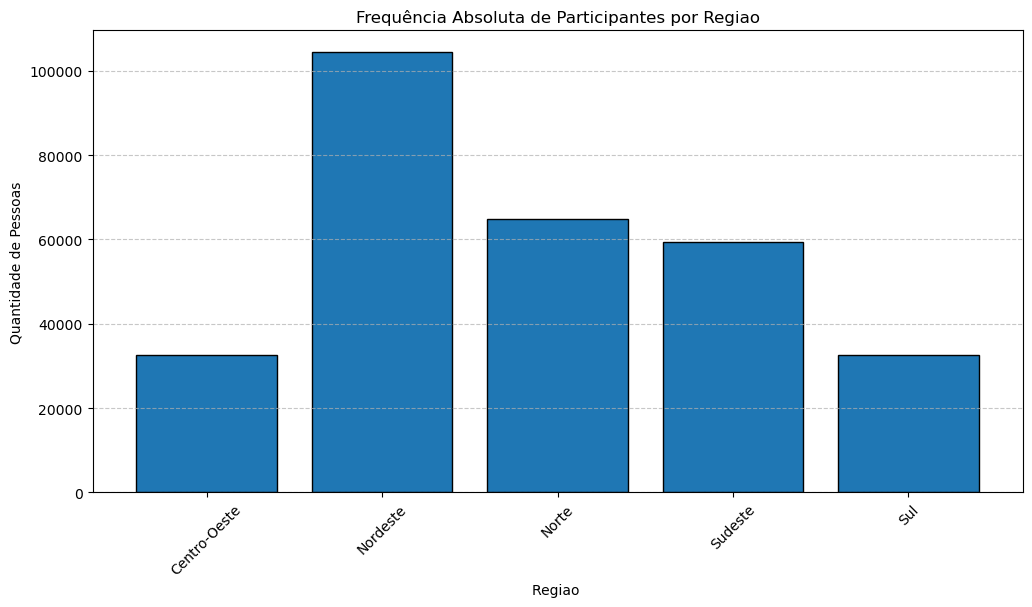

In [47]:
contagem_geral_regiao = df['Regiao'].value_counts().sort_index()
contagem_geral_regiao.plot(kind ='bar', edgecolor='black', figsize=(12, 6), width=0.8)
plt.title('Frequência Absoluta de Participantes por Regiao')
plt.xlabel('Regiao ')
plt.ylabel('Quantidade de Pessoas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

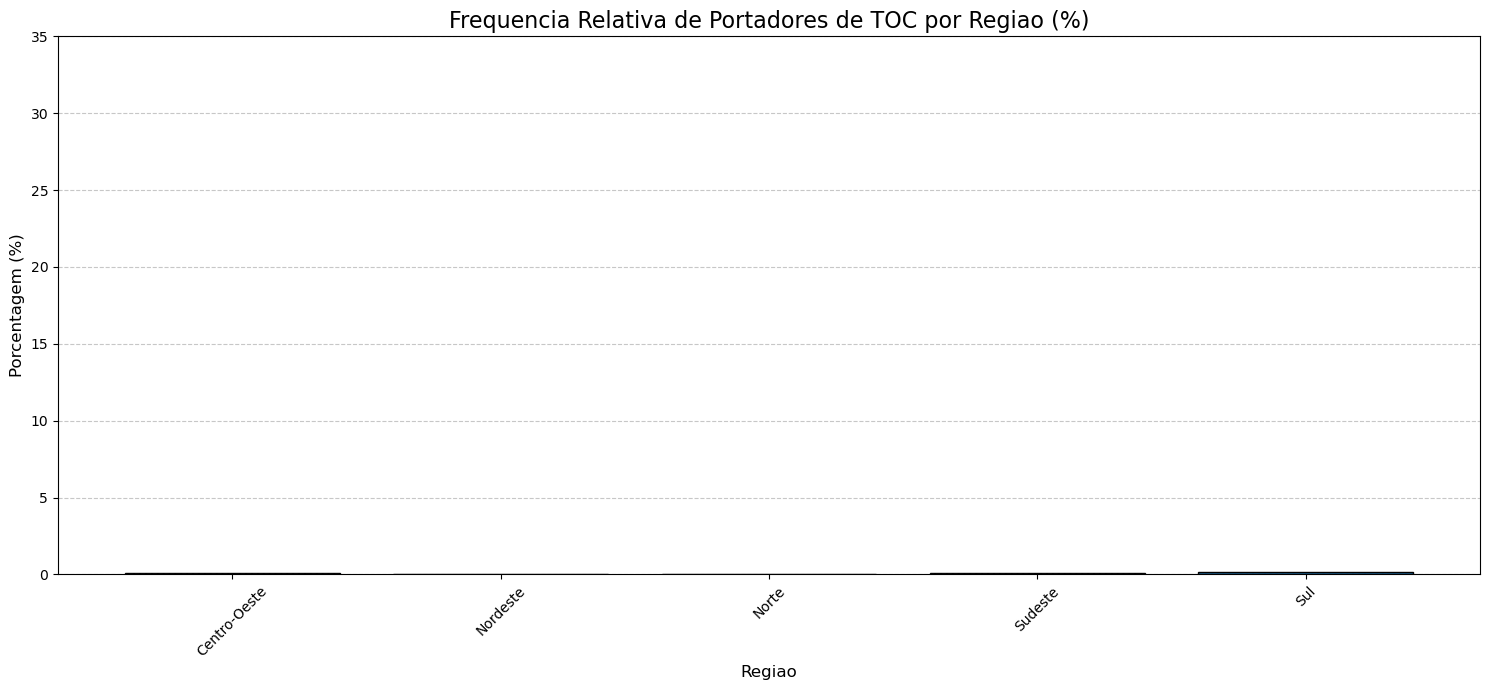

In [50]:
porcentagem_toc_regiao = (contagem_toc_regiao / contagem_geral_regiao) * 100
porcentagem_maior_estado = int(contagem_geral_regiao.max() / contagem_geral_regiao.sum()* 100)
plt.figure(figsize=(15, 7))
porcentagem_toc_regiao.plot(kind='bar', edgecolor='black', width=0.8)
plt.ylim(0,porcentagem_maior_estado)
plt.title('Frequencia Relativa de Portadores de TOC por Regiao (%)', fontsize=16)
plt.xlabel('Regiao', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Colunas Interresantes

V0001 Unidade da Federação
C006 Sexo
C008 Idade do morador na data de referência
P00104 Peso - Final (em kg)
P00404 Altura - Final (em cm)
P01001 Em geral, o(a) Sr(a) costuma comer esse tipo de verdura ou legume
P01101 Em quantos dias da semana o(a) Sr(a) costuma comer carne vermelha (boi, porco, cabrito, bode, ovelha etc.)? 
P013 Em quantos dias da semana o(a) Sr(a) costuma comer frango/galinha?
P02001	Suco de caixinha/lata/pó
P01601	Suco natural
P018	Frutas
P02002	Refrigerante
P023	Leite
P02501	Docesbebida alcoólica
P02801	Frequência diária de bebidas alcoólicas (p027)
P02101	Tipo de suco industrializado (p02001)
P02102	Frequencia de Refrigerante (p02002)
P02401	Tipo leite 
P035 Quantos dias por semana o(a) Sr(a) costuma  (costumava)praticar exercício físico ou esporte?
P050 Atualmente, o(a) Sr(a) fuma algum produto do tabaco? 